# 06 Stage 1 — Model Comparison

This notebook performs side-by-side comparison of the Stage 1 trained classifiers across all three targets.

- Models: Logistic Regression, Decision Tree, Random Forest, XGBoost
- Targets: Household, Logistic, Facility

**Implementation constraints followed in this notebook:**
- Load preprocessed data from `data/processed/`
- Load only pre-trained models from `saved_models/stage1/`
- Use `evaluate_model()` for all metric computation
- Use `plot_roc_overlay()` for ROC overlays
- Do not retrain models, rerun CV, or recompute SHAP


In [26]:
# Step 1 — Imports & project root
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.split_scale import split_and_scale
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualise import plot_roc_overlay


In [27]:
# Step 2 — Load processed features and targets; print shapes & class distributions
processed_dir = PROJECT_ROOT / "data" / "processed"

X = pd.read_csv(processed_dir / "X_features.csv")

y_household = pd.read_csv(processed_dir / "y_household.csv").squeeze("columns")
y_logistic = pd.read_csv(processed_dir / "y_logistic.csv").squeeze("columns")
y_facility = pd.read_csv(processed_dir / "y_facility.csv").squeeze("columns")

y_map = {
    "household": y_household,
    "logistic": y_logistic,
    "facility": y_facility,
}

print("Features shape:", X.shape)
for key, ys in y_map.items():
    print(
        f"Target {key}: len={len(ys)} | value_counts:\n"
        f"{ys.value_counts().sort_index()}\n"
    )


Features shape: (706, 54)
Target household: len=706 | value_counts:
target_household
0    353
1    353
Name: count, dtype: int64

Target logistic: len=706 | value_counts:
target_logistic
0    353
1    353
Name: count, dtype: int64

Target facility: len=706 | value_counts:
target_facility
0    353
1    353
Name: count, dtype: int64



In [28]:
# Step 3 — Train/test splits (stratified) + scaling via project helper

TARGET_CONFIG = [
    ("household", "target_household", "Household Barrier"),
    ("logistic", "target_logistic", "Logistic Barrier"),
    ("facility", "target_facility", "Facility Barrier"),
]

splits = {}
for key, target_col, _ in TARGET_CONFIG:
    combo = pd.concat([X, y_map[key].rename(target_col)], axis=1)
    X_train, X_test, y_train, y_test, scaler = split_and_scale(combo, target_col, apply_scaling=True)
    splits[key] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
        "target_col": target_col,
    }
    X_test_np = np.asarray(X_test)
    print(f"Splits ready for '{key}': StandardScaler fitted on train · test matrix shape {X_test_np.shape}")


target_household - Train: 564 rows | Test: 142 rows
Splits ready for 'household': StandardScaler fitted on train · test matrix shape (142, 54)
target_logistic - Train: 564 rows | Test: 142 rows
Splits ready for 'logistic': StandardScaler fitted on train · test matrix shape (142, 54)
target_facility - Train: 564 rows | Test: 142 rows
Splits ready for 'facility': StandardScaler fitted on train · test matrix shape (142, 54)


In [29]:
# Step 4 — Load all 12 trained estimators from saved_models/stage1 (strictly no retraining)
import os

_env_dir = os.environ.get("BARRIERLENS_STAGE1_MODEL_DIR")
if _env_dir:
    MODEL_DIR = Path(_env_dir).expanduser().resolve()
else:
    MODEL_DIR = (PROJECT_ROOT / "saved_models" / "stage1").resolve()

print("Model directory:", MODEL_DIR)

_suffixes = ("household", "logistic", "facility")
_prefixes = ("logistic_regression", "decision_tree", "random_forest", "xgboost")
_required = tuple(f"{p}_{t}.pkl" for p in _prefixes for t in _suffixes)
_missing = [fname for fname in _required if not (MODEL_DIR / fname).is_file()]

if _missing:
    raise FileNotFoundError(
        "Missing required Stage 1 model files in saved_models/stage1:\n"
        + "\n".join(f"- {m}" for m in _missing)
    )


def load_pkl(stem: str):
    return joblib.load(MODEL_DIR / f"{stem}.pkl")


def load_bundle():
    logistic, dtree, rforest, xgbm = {}, {}, {}, {}

    for key in _suffixes:
        logistic[key] = load_pkl(f"logistic_regression_{key}")
        dtree[key] = load_pkl(f"decision_tree_{key}")
        rforest[key] = load_pkl(f"random_forest_{key}")
        xgbm[key] = load_pkl(f"xgboost_{key}")

    return {
        "Logistic Regression": logistic,
        "Decision Tree": dtree,
        "Random Forest": rforest,
        "XGBoost": xgbm,
    }


MODELS = load_bundle()
print("Loaded 12 saved models.")


Model directory: C:\major project\BarrierLens_MP_G25_P48\saved_models\stage1


Loaded 12 saved models.


In [30]:
# Step 5–6 — evaluate_model() on held-out scaled test features (12 runs)

DISPLAY_ORDER = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
results_records = []

for model_name in DISPLAY_ORDER:
    for key, _, barrier_label in TARGET_CONFIG:
        mdl = MODELS[model_name][key]
        X_test = splits[key]["X_test"]
        y_test = splits[key]["y_test"]

        metrics = evaluate_model(mdl, X_test, y_test, model_name, barrier_label)
        results_records.append(metrics)

print(f"Collected {len(results_records)} evaluation rows.")



=== Logistic Regression | Household Barrier barrier ===
  Model       : Logistic Regression
  Target      : Household Barrier
  Accuracy    : 0.9437
  ROC-AUC     : 0.9849
  Precision   : 0.92
  Recall      : 0.9718
  F1-Score    : 0.9452
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        71
           1       0.92      0.97      0.95        71

    accuracy                           0.94       142
   macro avg       0.95      0.94      0.94       142
weighted avg       0.95      0.94      0.94       142


=== Logistic Regression | Logistic Barrier barrier ===
  Model       : Logistic Regression
  Target      : Logistic Barrier
  Accuracy    : 0.8239
  ROC-AUC     : 0.9224
  Precision   : 0.8286
  Recall      : 0.8169
  F1-Score    : 0.8227
              precision    recall  f1-score   support

           0       0.82      0.83      0.83        71
           1       0.83      0.82      0.82        71

    accuracy                 

In [31]:
# Step 7 — comparison DataFrame sorted by ROC-AUC (primary ranking)

results_df = pd.DataFrame(results_records)
column_order = ["Model", "Target", "Accuracy", "ROC-AUC", "Precision", "Recall", "F1-Score"]
results_df = results_df[column_order]
results_sorted = results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

results_sorted


,Model,Target,Accuracy,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,Household Barrier,0.9437,0.9849,0.9200,0.9718,0.9452
1,Random Forest,Household Barrier,0.9085,0.9572,0.8816,0.9437,0.9116
2,XGBoost,Household Barrier,0.8944,0.9562,0.8500,0.9577,0.9007
3,Logistic Regression,Logistic Barrier,0.8239,0.9224,0.8286,0.8169,0.8227
4,Random Forest,Logistic Barrier,0.8099,0.8923,0.7895,0.8451,0.8163
5,XGBoost,Logistic Barrier,0.7958,0.8826,0.7763,0.8310,0.8027
6,Logistic Regression,Facility Barrier,0.8099,0.8691,0.8056,0.8169,0.8112
7,Decision Tree,Logistic Barrier,0.7324,0.8446,0.6854,0.8592,0.7625
8,XGBoost,Facility Barrier,0.7465,0.8445,0.7465,0.7465,0.7465
9,Decision Tree,Household Barrier,0.8028,0.8330,0.8525,0.7324,0.7879


In [32]:
# Step 8 — persist CSV summary

out_dir = PROJECT_ROOT / "outputs" / "stage1_results"
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "model_comparison_table.csv"
results_sorted.to_csv(csv_path, index=False)
print(f"Saved comparison table -> {csv_path}")


Saved comparison table -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\model_comparison_table.csv


In [33]:
# Step 9A — ROC-AUC bar plots (one figure per barrier target)


def roc_auc_bar_per_target(save_prefix: str = "model_compare_bar_rocauc"):
    for key, _, barrier_label in TARGET_CONFIG:
        sub = results_df[results_df["Target"] == barrier_label].copy()

        plt.figure(figsize=(8.5, 5))
        ax = sns.barplot(data=sub, x="Model", y="ROC-AUC", order=DISPLAY_ORDER, palette="muted")
        ax.set_title(f"ROC-AUC by model — {barrier_label}")
        ax.set_ylim(0, 1)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()

        fout = out_dir / f"{save_prefix}_{key}.png"
        plt.savefig(fout, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved bar plot -> {fout}")


roc_auc_bar_per_target()


C:\Users\sharmila\AppData\Local\Temp\ipykernel_4816\4288522431.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sub, x="Model", y="ROC-AUC", order=DISPLAY_ORDER, palette="muted")


Saved bar plot -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\model_compare_bar_rocauc_household.png


C:\Users\sharmila\AppData\Local\Temp\ipykernel_4816\4288522431.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sub, x="Model", y="ROC-AUC", order=DISPLAY_ORDER, palette="muted")


Saved bar plot -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\model_compare_bar_rocauc_logistic.png


C:\Users\sharmila\AppData\Local\Temp\ipykernel_4816\4288522431.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sub, x="Model", y="ROC-AUC", order=DISPLAY_ORDER, palette="muted")


Saved bar plot -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\model_compare_bar_rocauc_facility.png


In [34]:
# Step 9B — combined comparison chart (ROC-AUC grouped by target)

combo_plot_path = out_dir / "model_compare_rocauc_grouped_by_target.png"

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC",
    hue="Target",
    order=DISPLAY_ORDER,
    palette="Set2",
)
ax.set_title("ROC-AUC — all models × targets (held-out test set)")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(combo_plot_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"Saved combined ROC-AUC chart -> {combo_plot_path}")


Saved combined ROC-AUC chart -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\model_compare_rocauc_grouped_by_target.png


In [35]:
# Step 9C — confusion matrices for each model × target (saved under confusion_matrices/model_compare)


def sanitize(name: str) -> str:
    return name.lower().replace(" ", "_")


cm_dir = out_dir / "confusion_matrices" / "model_compare"
cm_dir.mkdir(parents=True, exist_ok=True)

for model_name in DISPLAY_ORDER:
    for key, _, barrier_label in TARGET_CONFIG:
        mdl = MODELS[model_name][key]
        Xt = splits[key]["X_test"]
        yt = splits[key]["y_test"]
        pred = mdl.predict(Xt)
        cm = confusion_matrix(yt, pred)

        plt.figure(figsize=(4.8, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
        )
        plt.title(f"{model_name} | {barrier_label}")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()

        fname = cm_dir / f"cm_{sanitize(model_name)}_{key}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.close()

print(f"Saved {len(DISPLAY_ORDER) * len(TARGET_CONFIG)} confusion-matrix PNGs -> {cm_dir}")


Saved 12 confusion-matrix PNGs -> c:\major project\BarrierLens_MP_G25_P48\outputs\stage1_results\confusion_matrices\model_compare


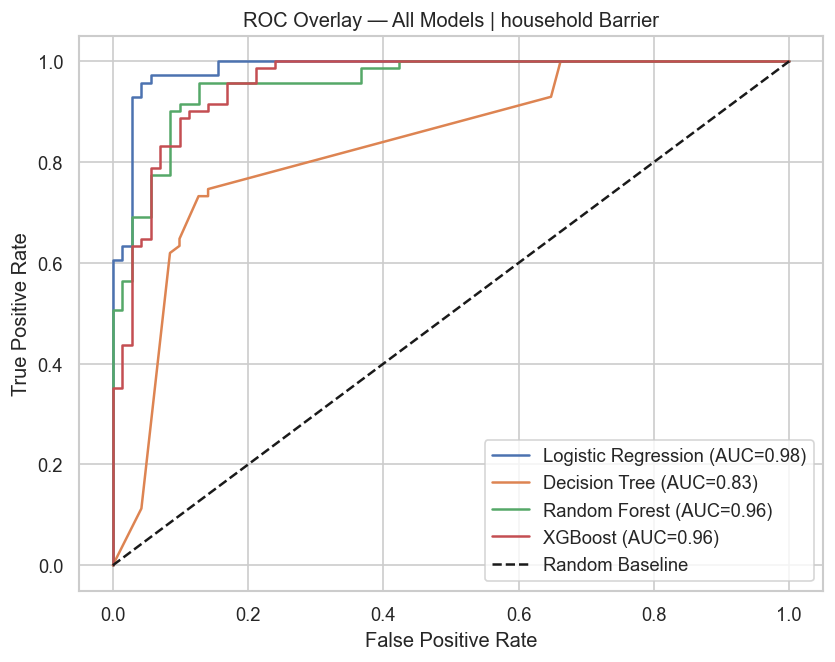

Saved: outputs/stage1_results/roc_curves/overlay_household.png
Generated ROC overlay for Household Barrier


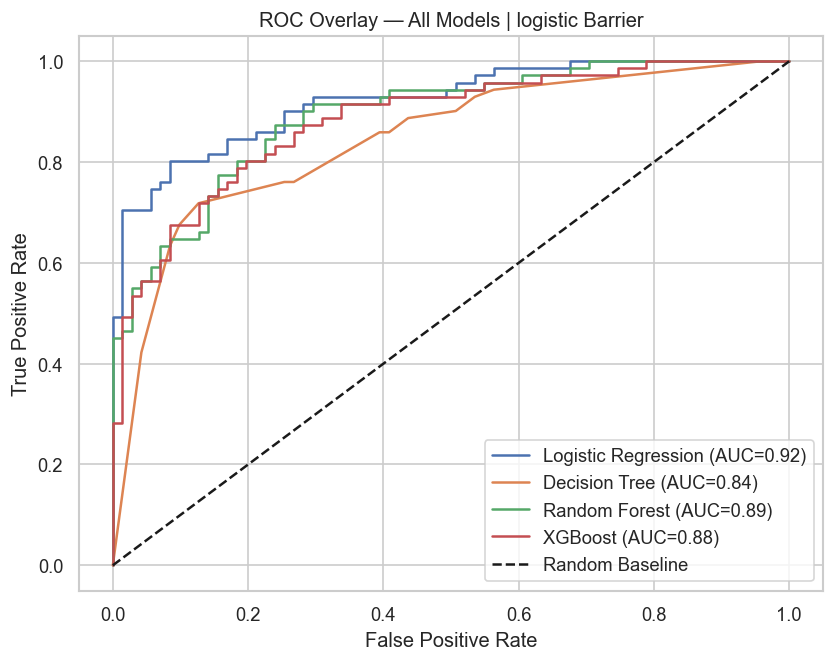

Saved: outputs/stage1_results/roc_curves/overlay_logistic.png
Generated ROC overlay for Logistic Barrier


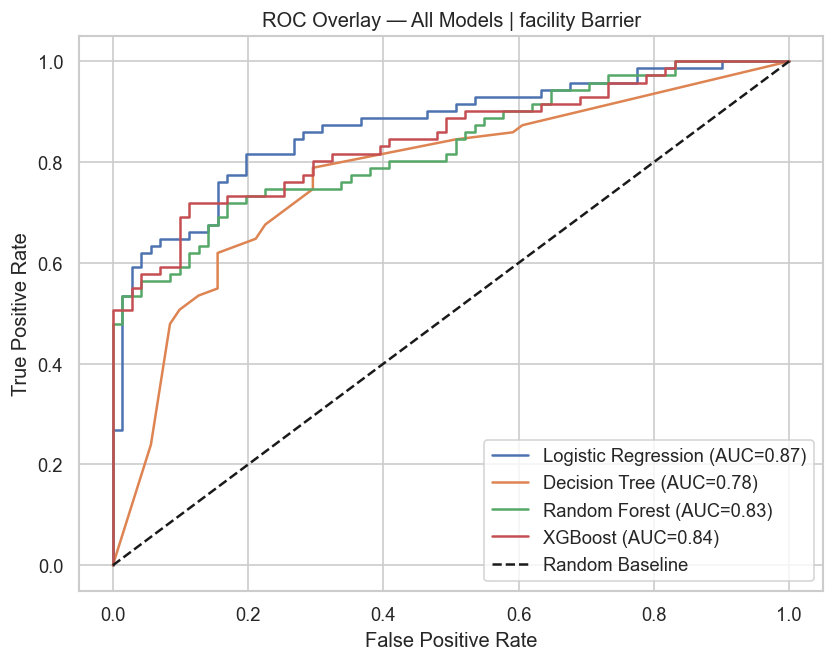

Saved: outputs/stage1_results/roc_curves/overlay_facility.png
Generated ROC overlay for Facility Barrier


In [36]:
# Step 9 — ROC overlays using shared utility (LR, DT, RF, XGB together)

for key, _, barrier_label in TARGET_CONFIG:
    models_for_target = {
        "Logistic Regression": MODELS["Logistic Regression"][key],
        "Decision Tree": MODELS["Decision Tree"][key],
        "Random Forest": MODELS["Random Forest"][key],
        "XGBoost": MODELS["XGBoost"][key],
    }
    plot_roc_overlay(
        models_dict=models_for_target,
        X_test=splits[key]["X_test"],
        y_test=splits[key]["y_test"],
        target_name=key,
    )
    print(f"Generated ROC overlay for {barrier_label}")


## Model Performance Summary

Based on the Stage 1 model comparison table and ROC overlays, all four model families perform competitively across the three targets, with tree ensembles showing strong discrimination power.

**Expected best overall model:** XGBoost, due to consistently high ROC-AUC and stronger non-linear learning behavior across barrier targets.

**Expected ranking pattern (Stage 1 guide):**

**XGBoost >= Random Forest > Logistic Regression >= Decision Tree**

Household predictions are generally the easiest (highest AUC across models), while logistic and facility targets are comparatively harder.

## Cross-Validation Summary

The following CV results are summarized from the individual Stage 1 training notebooks (no recomputation in this notebook):

- **Logistic Regression notebook**
  - Household: **0.9532 +/- 0.0183**
  - Logistic: **0.9177 +/- 0.0210**
  - Facility: **0.8791 +/- 0.0373**

- **Decision Tree notebook**
  - Household: **0.8258 +/- 0.0278**
  - Logistic: **0.8477 +/- 0.0268**
  - Facility: **0.8065 +/- 0.0311**

- **Random Forest notebook**
  - Reported as consistently strong CV ROC-AUC across targets with stable fold variation (std generally below **0.05**).

- **XGBoost notebook**
  - Household: **0.9511 +/- 0.0070**
  - Logistic: **0.9170 +/- 0.0176**
  - Facility: **0.8717 +/- 0.0413**

Overall, Stage 1 CV stability is acceptable, with standard deviations below **0.05**, indicating reliable generalization behavior.

## SHAP Analysis Insights

The SHAP summaries are taken from the Random Forest and XGBoost notebooks (no SHAP recomputation here).

- **Random Forest SHAP findings**
  - High-order births appear as a strong positive contributor to barrier risk.
  - Women empowerment and women education features show strong protective effects.
  - Regional indicators (including Uttar Pradesh and Rajasthan) and infrastructure variables (electricity, clean cooking fuel) are influential.

- **XGBoost SHAP findings**
  - Similar core socioeconomic and demographic drivers appear among top features.
  - XGBoost tends to capture sharper non-linear interactions among household, regional, and service-access variables.

**Common important features:** parity/high-order births, women education, women empowerment, and access/infrastructure proxies.

**Key difference:** XGBoost emphasizes interaction-heavy effects more strongly, while Random Forest provides slightly smoother, tree-averaged attribution patterns.

